## Pricing experiment analysis (synthetic Eskwelabs-style stack)

**Data:** CSV files in `output/` generated by `src/generator.py` or the companion generator notebook.

Sections:
1. **EDA** — distributions, missingness, correlation, segments, cohorts, treatment contrast
2. **A/B testing** — conversion, uplift, CIs, hypothesis tests
3. **Revenue** — ARPU / LTV perspectives, elasticity discussion
4. **Predictive modeling** — conversion + churn with multiple algorithms

**Causal lens:** arm assignment is randomized; person-level outcomes are still driven by **latent** WTP not in the CSV. That means treatment effect estimates from the experiment are **much more interpretable** than naïve regressions on observational slices.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd()
USERS = pd.read_csv(ROOT / "output" / "users.csv")
EXP = pd.read_csv(ROOT / "output" / "pricing_experiments.csv")
SUBS = pd.read_csv(ROOT / "output" / "subscriptions.csv")

# Person-level experiment facts (dedupe duplicate log rows)
EXP_USER = EXP.sort_values("experiment_row_id").drop_duplicates("user_id", keep="first")
USER_EXP = USERS.merge(EXP_USER, on="user_id", how="left", validate="one_to_one")
USER_SUB = USER_EXP.merge(SUBS, on="user_id", how="left", suffixes=("", "_sub"))
print(USERS.shape, EXP.shape, EXP_USER.shape, SUBS.shape)


(10000, 19) (10005, 15) (10000, 15) (1594, 17)


### Section 1 — EDA


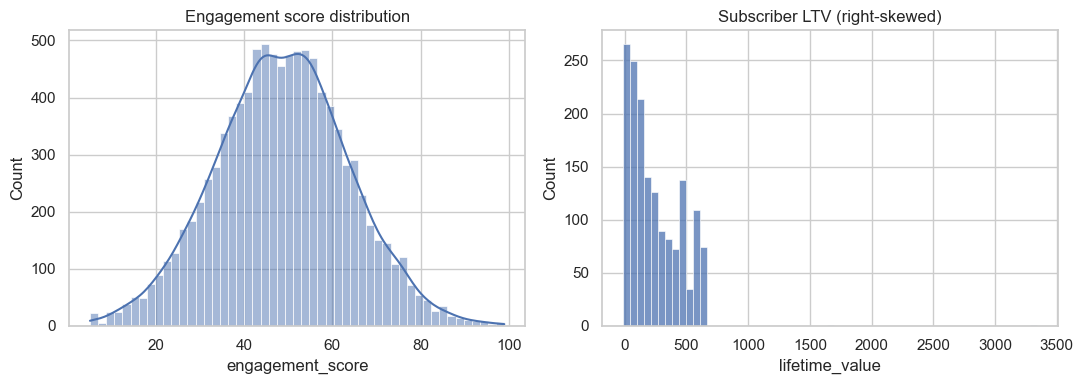

income_segment    0.0830
age               0.0546
dtype: float64

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(USERS["engagement_score"].dropna(), kde=True, ax=ax[0])
ax[0].set_title("Engagement score distribution")
if SUBS.shape[0]:
    sns.histplot(SUBS["lifetime_value"], kde=False, ax=ax[1])
    ax[1].set_title("Subscriber LTV (right-skewed)")
plt.tight_layout()
plt.show()

miss = USERS.isna().mean().sort_values(ascending=False)
miss[miss > 0]


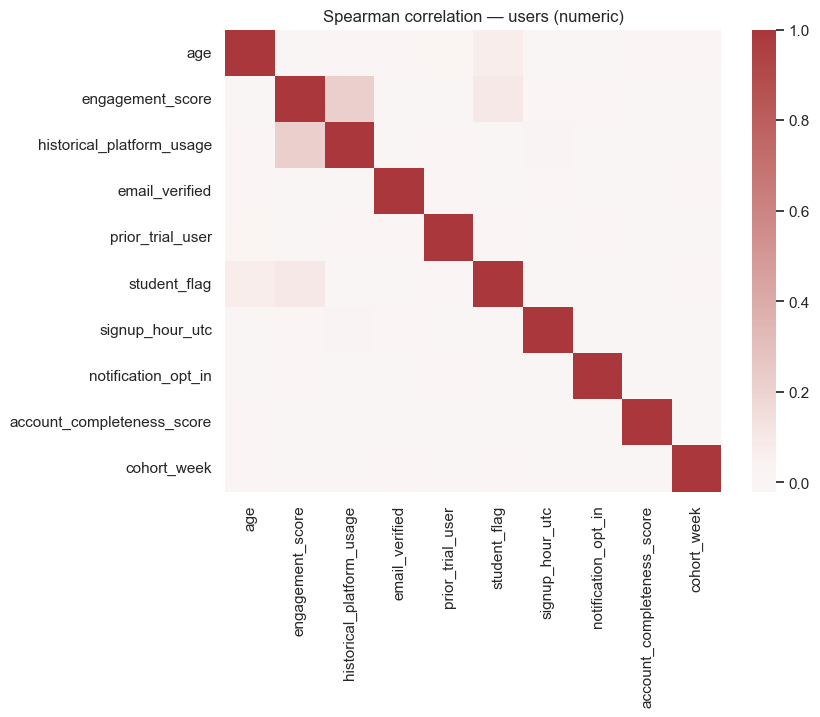

In [3]:
num_cols = [
    c for c in USERS.select_dtypes(include=["number"]).columns if c != "user_id"
]
corr = USERS[num_cols].corr(method="spearman")
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Spearman correlation — users (numeric)")
plt.show()


In [4]:
seg = (
    USER_EXP.groupby("country", dropna=False)["subscribed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "conversion_rate"})
)
seg.sort_values("conversion_rate", ascending=False).head(10)


,conversion_rate,count
country,,
NG,0.189597,596
SG,0.168337,499
AU,0.166134,939
GB,0.166033,789
DE,0.162872,571
US,0.161624,2710
CA,0.153547,1029
PH,0.148936,1222
IN,0.148188,938


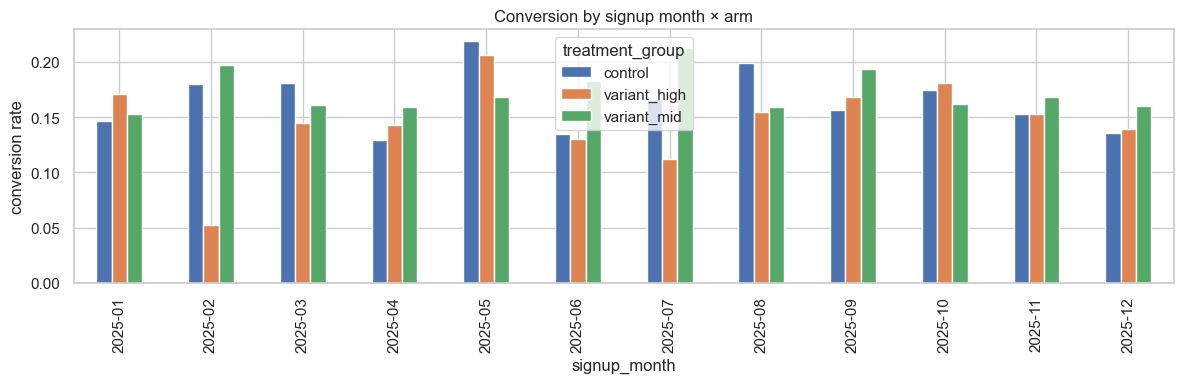

treatment_group,control,variant_high,variant_mid
signup_month,,,
2025-08,0.198413,0.154412,0.158940
2025-09,0.156028,0.167832,0.193798
2025-10,0.174825,0.181208,0.161765
2025-11,0.152318,0.152672,0.167939
2025-12,0.135802,0.139344,0.159722


In [5]:
cohort = USER_EXP.copy()
cohort["signup_date"] = pd.to_datetime(cohort["signup_date"])
cohort["signup_month"] = cohort["signup_date"].dt.to_period("M").astype(str)
tbl = cohort.groupby(["signup_month", "treatment_group"])["subscribed"].mean().unstack()
tbl.iloc[-12:].plot(kind="bar", figsize=(12, 4), title="Conversion by signup month × arm")
plt.ylabel("conversion rate")
plt.tight_layout()
plt.show()
tbl.tail()


In [6]:
tbl_trt = (
    USER_EXP.groupby("treatment_group")[["subscribed"]]
    .agg(conversion_rate=("subscribed", "mean"), n=("subscribed", "count"))
    .sort_values("conversion_rate", ascending=False)
)
tbl_trt


,conversion_rate,n
treatment_group,,
control,0.168881,3387
variant_mid,0.164454,3314
variant_high,0.144589,3299


### Section 2 — A/B testing

We compare Bernoulli conversion across arms using:
- **two-proportion z-test** (`statsmodels.stats.proportion.proportions_ztest`)
- **Welch's t-test** as a pedagogical analogue on `{0,1}` outcomes (equivalent variance not assumed)
- **bootstrap percentile CIs** for pairwise uplift

**Multiple comparisons:** three arms imply three pairwise tests if exploring all contrasts; Holm correction shown.


In [7]:
arms = ["control", "variant_mid", "variant_high"]
results = {}


def arm_stats(df, arm_name):
    s = df.loc[df["treatment_group"] == arm_name, "subscribed"]
    return int(s.sum()), int(len(s))


for a in arms:
    results[a] = arm_stats(USER_EXP, a)
results


{'control': (572, 3387),
 'variant_mid': (545, 3314),
 'variant_high': (477, 3299)}

In [8]:
(s0, n0) = results["control"]
(s1, n1) = results["variant_high"]
stat_z, pval_z = proportions_ztest([s0, s1], [n0, n1])
delta = s1 / n1 - s0 / n0
rel_uplift = delta / max(s0 / n0, 1e-9)
stat_z, pval_z, delta, rel_uplift


(np.float64(2.7304165971828236),
 np.float64(0.0063254336087101735),
 -0.02429174617246746,
 -0.1438394130876701)

In [9]:
rng = np.random.default_rng(42)


def bootstrap_conv_diff(df, arm_a, arm_b, reps=2500):
    da = df.loc[df["treatment_group"] == arm_a, "subscribed"].to_numpy()
    db = df.loc[df["treatment_group"] == arm_b, "subscribed"].to_numpy()
    out = np.empty(reps)
    for i in range(reps):
        sa = rng.choice(da, size=len(da), replace=True).mean()
        sb = rng.choice(db, size=len(db), replace=True).mean()
        out[i] = sb - sa
    return out


diff = bootstrap_conv_diff(USER_EXP, "control", "variant_high")
lo, hi = np.quantile(diff, [0.025, 0.975])
pd.Series({"mean_diff": diff.mean(), "ci95_lo": lo, "ci95_hi": hi})


mean_diff   -0.024407
ci95_lo     -0.041336
ci95_hi     -0.006895
dtype: float64

In [10]:
# Pairwise z-tests (uncorrected) + Holm adjustment
pairs = [("control", "variant_mid"), ("control", "variant_high"), ("variant_mid", "variant_high")]
raw_p = []
for a, b in pairs:
    sa, na = results[a]
    sb, nb = results[b]
    _, p = proportions_ztest([sa, sb], [na, nb])
    raw_p.append(p)
rej, p_holm, _, _ = multipletests(raw_p, method="holm")
pd.DataFrame({"pair": pairs, "p_uncorrected": raw_p, "p_holm": p_holm, "reject_holm": rej})


,pair,p_uncorrected,p_holm,reject_holm
0,"(control, variant_mid)",0.626852,0.626852,False
1,"(control, variant_high)",0.006325,0.018976,True
2,"(variant_mid, variant_high)",0.025452,0.050904,False


In [11]:
# t-test on binary outcome (illustrative; z-test is standard for proportions)
x0 = USER_EXP.loc[USER_EXP["treatment_group"] == "control", "subscribed"]
x1 = USER_EXP.loc[USER_EXP["treatment_group"] == "variant_high", "subscribed"]
stats.ttest_ind(x0, x1, equal_var=False)


TtestResult(statistic=np.float64(2.7338033718918764), pvalue=np.float64(0.006277248103996142), df=np.float64(6674.924479145427))

### Section 3 — Revenue analysis

**Intent-to-treat revenue** per assigned user can be constructed by merging subscriber revenue (zeros for non-subscribers). This keeps the randomization story coherent.

**Elasticity:** price moves change both conversion and retention in this simulator; naive price–quantity slopes on observational data confound segment mix and latent WTP — see causal discussion below.


In [12]:
rev_user = USER_EXP.merge(
    SUBS[["user_id", "total_revenue", "lifetime_value"]], on="user_id", how="left"
)
rev_user["total_revenue"] = rev_user["total_revenue"].fillna(0.0)
rev_user["lifetime_value"] = rev_user["lifetime_value"].fillna(0.0)

arpu_assigned = rev_user.groupby("treatment_group")["total_revenue"].mean()
arpu_subscriber = rev_user.loc[rev_user["subscribed"] == 1].groupby("treatment_group")["total_revenue"].mean()
pd.DataFrame({"ARPU_all_assigned": arpu_assigned, "ARPU_subscribers_only": arpu_subscriber})


,ARPU_all_assigned,ARPU_subscribers_only
treatment_group,,
control,42.398152,251.053392
variant_high,43.808260,302.984172
variant_mid,48.596777,295.504073


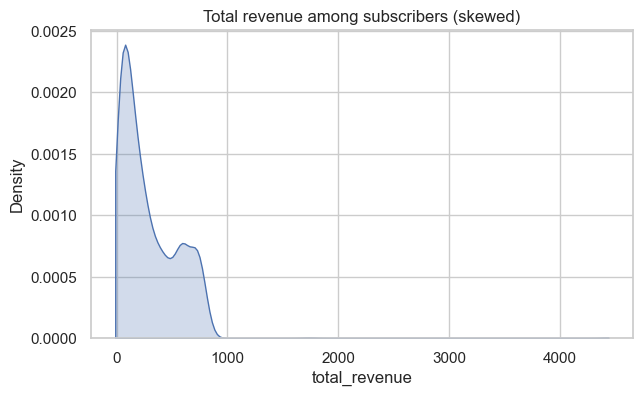

In [13]:
if SUBS.shape[0]:
    plt.figure(figsize=(7, 4))
    sns.kdeplot(SUBS["total_revenue"], fill=True, cut=0)
    plt.title("Total revenue among subscribers (skewed)")
    plt.show()


### Section 4 — Predictive modeling


In [14]:
feature_cols = [
    "age",
    "engagement_score",
    "historical_platform_usage",
    "email_verified",
    "prior_trial_user",
    "student_flag",
    "country",
    "device_type",
    "traffic_source",
    "income_segment",
    "assigned_price",
    "discount_pct",
]
X = USER_EXP[feature_cols].copy()
y = USER_EXP["subscribed"].astype(int)

num_features = [
    "age",
    "engagement_score",
    "historical_platform_usage",
    "email_verified",
    "prior_trial_user",
    "student_flag",
    "assigned_price",
    "discount_pct",
]
cat_features = ["country", "device_type", "traffic_source", "income_segment"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


def report_model(name, pipe):
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    pr = pipe.predict_proba(X_test)[:, 1]
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, p, average="binary", zero_division=0
    )
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, p),
        "roc_auc": roc_auc_score(y_test, pr),
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "pipe": pipe,
    }


rows = []
rows.append(
    report_model(
        "logistic_l2",
        Pipeline(
            [
                ("prep", clone(preprocess)),
                ("clf", LogisticRegression(max_iter=200, class_weight="balanced")),
            ]
        ),
    )
)
rows.append(
    report_model(
        "random_forest",
        Pipeline(
            [
                ("prep", clone(preprocess)),
                (
                    "clf",
                    RandomForestClassifier(
                        n_estimators=200,
                        max_depth=10,
                        random_state=42,
                        class_weight="balanced_subsample",
                    ),
                ),
            ]
        ),
    )
)

try:
    from xgboost import XGBClassifier

    rows.append(
        report_model(
            "xgboost",
            Pipeline(
                [
                    ("prep", clone(preprocess)),
                    (
                        "clf",
                        XGBClassifier(
                            n_estimators=300,
                            max_depth=4,
                            learning_rate=0.05,
                            subsample=0.9,
                            colsample_bytree=0.8,
                            random_state=42,
                            eval_metric="logloss",
                        ),
                    ),
                ]
            ),
        )
    )
except Exception as e:
    print("XGBoost unavailable:", e)

rows.append(
    report_model(
        "mlp",
        Pipeline(
            [
                ("prep", clone(preprocess)),
                (
                    "clf",
                    MLPClassifier(
                        hidden_layer_sizes=(64, 32),
                        max_iter=300,
                        random_state=42,
                        early_stopping=True,
                    ),
                ),
            ]
        ),
    )
)

summary = pd.DataFrame([{k: v for k, v in r.items() if k != "pipe"} for r in rows])
summary


XGBoost unavailable: No module named 'xgboost'


,model,accuracy,roc_auc,precision,recall,f1
0,logistic_l2,0.7120,0.784217,0.316210,0.695980,0.434851
1,random_forest,0.7548,0.775611,0.344428,0.597990,0.437098
2,mlp,0.8428,0.771253,0.592593,0.040201,0.075294


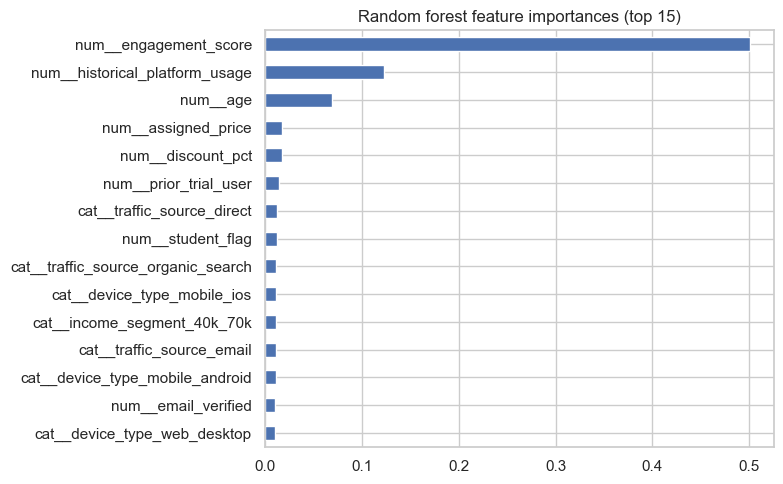

In [15]:
# Feature importances (Random Forest on one-hot space)
rf_row = [r for r in rows if r["model"] == "random_forest"][0]
rf = rf_row["pipe"].named_steps["clf"]
prep = rf_row["pipe"].named_steps["prep"]
feat_names = prep.get_feature_names_out()
imp = (
    pd.Series(rf.feature_importances_, index=feat_names)
    .sort_values(ascending=False)
    .head(15)
)
imp.sort_values().plot.barh(
    figsize=(8, 5), title="Random forest feature importances (top 15)"
)
plt.tight_layout()
plt.show()


In [16]:
# Churn model (subscribers only)
if SUBS.shape[0]:
    churn_df = USER_SUB.loc[USER_SUB["subscribed"] == 1].copy()
    churn_df["churned"] = churn_df["churned"].fillna(0).astype(int)
    Xc = churn_df[feature_cols].copy()
    yc = churn_df["churned"]
    Xtr, Xte, ytr, yte = train_test_split(
        Xc, yc, test_size=0.25, random_state=7, stratify=yc
    )
    churn_pipe = Pipeline(
        [
            ("prep", clone(preprocess)),
            ("clf", LogisticRegression(max_iter=300, class_weight="balanced")),
        ]
    )
    churn_pipe.fit(Xtr, ytr)
    pc = churn_pipe.predict_proba(Xte)[:, 1]
    print("Churn ROC-AUC", roc_auc_score(yte, pc))
    print(classification_report(yte, churn_pipe.predict(Xte), zero_division=0))
else:
    print("No subscribers — skip churn model")


Churn ROC-AUC 0.6177721088435374
              precision    recall  f1-score   support

           0       0.22      0.52      0.31        63
           1       0.88      0.65      0.75       336

    accuracy                           0.63       399
   macro avg       0.55      0.59      0.53       399
weighted avg       0.77      0.63      0.68       399



### Causal inference discussion (pricing experiments)

- **Pricing experiments are causal questions:** we manipulate **assigned price** (`treatment_group`) to learn how demand-side outcomes (`subscribed`, `total_revenue`) respond under randomized assignment — an **intent-to-treat / ATE** style estimand across arms.

- **Regression alone is insufficient** without clear identifying assumptions: pooled OLS correlating observational engagement with churn confounds latent **intrinsic engagement** that was never exported yet affects both churn and proxies.

- **Omitted-variable bias:** WTP enters the structural conversion and churn equations but analysts only see imperfect covariates. Randomization eliminates **baseline** imbalance in WTP across arms **in expectation**, but regressions conditioned on collapsible mediators risk **post-stratification** biases if used naïvely for total effects.

- **Treatment effects vs prediction:** Tree and gradient boosting models may improve **ROC-AUC** for conversion and churn, but coefficients from regularized logistic regression remain more **interpretable** for linear-in-index storytelling and partial dependencies.

---

**Interpretability vs predictive power:**
- Prefer **sparse / linear** models early in product workflows and for stakeholder communication.
- Prefer **ensemble / boosted** learners when uplift ranking, credit risk style screening, or policy targeting dominates and audit trails allow SHAP/post-hoc probes (not exercised here).

Re-run notebooks after regenerating CSVs — metrics will move with `--seed`.
